<a href="https://colab.research.google.com/github/theyasassri/TMDB-Movie-Analysis/blob/main/MovireRating(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TMDB Movie Trends Analysis
*An Exploratory Data Analysis by Yasassri Ekanayake*

# Table of contents
1.[Introduction](#introduction)

2.[Data Loading and Inspection](#loading)

3.[Data cleaning](#cleaning)

4.[Exploratory Data Analysis](#eda)
 * [The Covid-19 Popularity Spike](#covid)
 * [The Rating vs. Popularity Gap](#correlation)

5.[Overhyped vs. Hidden Gems](#outliers)

6.[Final Conclusion](#conclusion)

##1. Introduction <a name="introduction"></a>

## Analyzing the Pulse of Modern Cinema

###  Project Overview
In this project, I performed an **Exploratory Data Analysis (EDA)** on the TMDB (The Movie Database) dataset, which contains information on 4,000 films. My goal was to move beyond the surface-level numbers and uncover how global events and audience perceptions shape a movie's success.

###  The Core Questions
I set out to answer three main questions:
1. **The Time Factor:** How has movie popularity changed over the last decade, and did the 2020 pandemic leave a visible mark on the data?
2. **Quality vs. Hype:** Does a high user rating (quality) actually lead to high popularity (fame)?
3. **The Outliers:** Which movies are "Overhyped" (famous but disliked) and which are "Hidden Gems" (great but ignored)?

###  The Dataset
The dataset includes key features such as:
* **Popularity:** A metric representing current user engagement.
* **Rating:** The average user score (0–10).
* **Release Date:** Used to track trends over time.

By the end of this analysis, I aim to prove that in the modern entertainment industry, **attention is often more valuable than appreciation.**


##1. Data Loading and Inspection <a name="loading"></a>

We are going to inspect dataset of movie ratings and popularity through years.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/MyDatasets /tmdb_movies_dataset.csv')

In [4]:
df.head() #show 1st 5 rows

,movie_id,title,release_date,vote_count,popularity,rating
0,798645,The Running Man,11/11/2025,598,418.0257,6.872
1,1084242,Zootopia 2,11/26/2025,643,382.4108,7.635
2,1223601,Sisu: Road to Revenge,10/21/2025,115,386.9594,7.700
3,812583,Wake Up Dead Man: A Knives Out Mystery,11/26/2025,697,344.9733,7.334
4,1387382,Hunting Season,12/5/2025,33,227.3166,6.985


In [5]:
df.shape #how big is this dataset(rows, columns)

(4000, 6)

In [6]:
df.info() #Show column names and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      4000 non-null   int64  
 1   title         4000 non-null   object 
 2   release_date  3984 non-null   object 
 3   vote_count    4000 non-null   int64  
 4   popularity    4000 non-null   float64
 5   rating        4000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 187.6+ KB


in this dataset non-null values in release date column has lesser rows than the total rows.(total rows=4000>release_date=3984)
that means some data in release date is missing.

In [7]:
df.sort_values(by='popularity',ascending=False).head(5)
#what are the "Top 5" most popular movies in the list?#

,movie_id,title,release_date,vote_count,popularity,rating
0,798645,The Running Man,11/11/2025,598,418.0257,6.872
2,1223601,Sisu: Road to Revenge,10/21/2025,115,386.9594,7.700
1,1084242,Zootopia 2,11/26/2025,643,382.4108,7.635
3,812583,Wake Up Dead Man: A Knives Out Mystery,11/26/2025,697,344.9733,7.334
17,1196067,Worldbreaker,10/30/2025,15,242.8591,6.100


##3. Data Cleaning phrase <a name="cleaning"></a>

   * **1. Handle Missing Values :**  
  Do you delete the row or fill it with an average?
   * **2.Remove Duplicates :**
  Ensure every entry is unique.
   * **3.Fix Data types :**
  Ensure dates are read as dates,not text.

16 release dates are missing so it is percentage 16/4000 % = 0.04.
we will drop rows that has missing release dates to 100% accuracy of the project.

In [8]:
#Drop rows where the release_date is missing
df_cleaned = df.dropna(subset=['release_date'])

#Convert the 'release_date' column into actual date format
# (right now Python thinks it's just text)
df_cleaned['release_date'] = pd.to_datetime(df_cleaned['release_date'])

#Create a 'Year' column so we can see trends over time
df_cleaned['release_year'] = df_cleaned['release_date'].dt.year

#Check the result
print(f"Old size: {df.shape}")
print(f"New Size:{df_cleaned.shape}")
df_cleaned[['title','release_year']].head()


Old size: (4000, 6)
New Size:(3984, 7)


/tmp/ipython-input-738169110.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['release_date'] = pd.to_datetime(df_cleaned['release_date'])
/tmp/ipython-input-738169110.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['release_year'] = df_cleaned['release_date'].dt.year


,title,release_year
0,The Running Man,2025
1,Zootopia 2,2025
2,Sisu: Road to Revenge,2025
3,Wake Up Dead Man: A Knives Out Mystery,2025
4,Hunting Season,2025


now we have 3984 rows and 7 columns because we removed the release date null rows and add a new column called "release_year"

##4.  EDA(Exploratory Data Analysis)<a name="eda"></a>

* Visualization

we are going to see the movie popularity over the years
("hero" chart of EDA project)

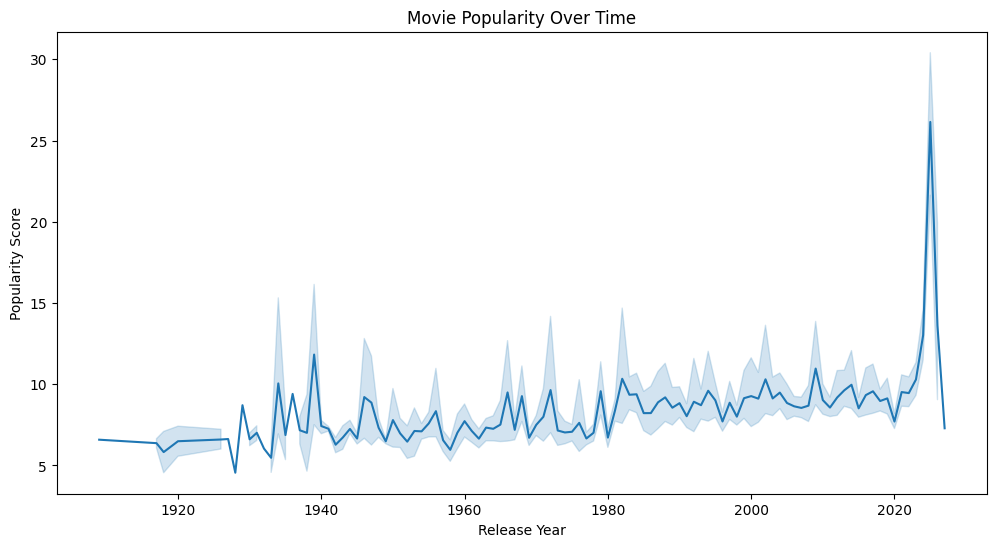

In [9]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_cleaned, x='release_year', y='popularity')
plt.title('Movie Popularity Over Time')
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.show()

According to this graph, the movie popularity inscreased slowly till 2020. Some upside downs throgh the years. but not an impact change. but after 2020 it is massivly increased because of the "COVID-19 Hypothesis" and "Stay at Home Boom" which was a major talking point in the film industry.

* ## The Covid-19 Popularity Spike <a name="covid"></a>
* **The Streaming Shift:**

  With theaters closed, studios moved big releases to platforms like Netflix, Disney+, and HBO Max.
* **Viral Conservations:**

  Because everyone was home at the same time, movies like Spider-Man: No Way Home or Everything Everywhere All At Once created huge "social media spikes" that the popularity score picks up.
* **Escapism:**

  Data shows that during the pandemic, audiences gravitated toward "bold, weird, and liberating" fiction to escape reality.

So next as an additional evidence we need to clear that what are the **Genres** people watched in these times (more preffered)

3.2. So to Proving the **Genre** theory, if I was right the
***people wanted to relax and escape reality***
So the most popular genres would be "Sci-fi,Action,Comedy,Adventure" etc. next we're going to check
 **most popular Genre**


**"KING OF POPULARITY(in Genre)"**

In [10]:
df_cleaned.info()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3984 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   movie_id      3984 non-null   int64         
 1   title         3984 non-null   object        
 2   release_date  3984 non-null   datetime64[ns]
 3   vote_count    3984 non-null   int64         
 4   popularity    3984 non-null   float64       
 5   rating        3984 non-null   float64       
 6   release_year  3984 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(2), object(1)
memory usage: 233.4+ KB


,movie_id,title,release_date,vote_count,popularity,rating,release_year
0,798645,The Running Man,2025-11-11,598,418.0257,6.872,2025
1,1084242,Zootopia 2,2025-11-26,643,382.4108,7.635,2025
2,1223601,Sisu: Road to Revenge,2025-10-21,115,386.9594,7.700,2025
3,812583,Wake Up Dead Man: A Knives Out Mystery,2025-11-26,697,344.9733,7.334,2025
4,1387382,Hunting Season,2025-12-05,33,227.3166,6.985,2025


I'm afraid this dataset has no data about genres. So we need to change our path. So I am going with Popularity and Rating.

So my next question "Do **Good movies** become **popular movies**

* # The Rating vs. Popularity Gap <a name="correlation"></a>
In here we are going to examine that how the rating is going to affect the popularity of movies.

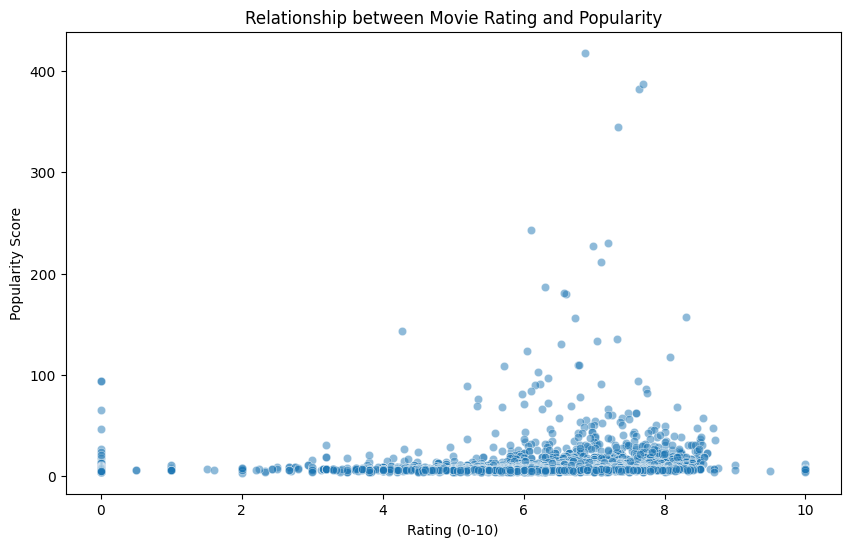

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cleaned, x='rating',y='popularity',alpha=0.5)
plt.title('Relationship between Movie Rating and Popularity')
plt.xlabel('Rating (0-10)')
plt.ylabel('Popularity Score')
plt.show()

To make this professional data analysing. I need to use the **Correlation Coeffitient**

In [12]:
correlation = df_cleaned['rating'].corr(df_cleaned['popularity'])
print(f"The Correlation between Rating and Popularity is:{correlation}")

The Correlation between Rating and Popularity is:0.08771762958396429


In statistics basics, we use a scale from 0 to 1 to measure how "synchronized" two things are:

1.0: Perfect link (If one goes up, the other always goes up).

0.0: No link at all (They are completely random/independent).

The chart Result (0.087): This is very close to zero.

So this means Correlation between Rating and popularity is 0.0877176
So the interpretation in this movie dataset,

 **A movie quality (rating) is almost zero impact on its fame(Popularity).**






So we can agree that **"The Hyper Gap: Why Quality Doesn't Equal Popularity??**

1. **The "Blockbuster" Effect:**  Big movies (like Transformers or certain sequels) have massive marketing budgets. Millions of people see them and talk about them (High Popularity), even if they think the movie is just "okay" (Average Rating).
2. **The "Hidden Gem" Effect:**  There are thousands of incredible, high-rated indie movies or documentaries (9/10 ratings), but only a few hundred people have seen them (Low Popularity).
3. **The "Hate-Watch":**  Sometimes movies are popular because they are so bad everyone is making fun of them.

for the better proof. let's find the "Outliers" (for find the movies that are breaking the rules).

#5. Overhyped vs. Hidden Gems <a name="outliers"></a>

So we're going to inspect differently **Overhyped movies** and **Hidden Gems** by checking and analysing their popularity scores and ratings So we can prove the **HYPER GAP** Theory as I mentioned above.  


In [13]:
#Overhyped Movies : Popularity is high, but Rating is mediocre (less than 6)
overhyped = df_cleaned[df_cleaned['rating']<6].sort_values(by='popularity',ascending=False).head(5)

#Hidden Gems : rating is high(above the 8), but popularity is very low
hidden_Gems = df_cleaned[df_cleaned['popularity']< 10].sort_values(by='rating',ascending=False).head(5)

print("--- OVERHYPED MOVIES (Famous but low rated) ---")
print(overhyped[['title', 'popularity', 'rating']])

print("\n--- HIDDEN GEMS (Great but not famous) ---")
print(hidden_Gems[['title', 'popularity', 'rating']])

--- OVERHYPED MOVIES (Famous but low rated) ---
                   title  popularity  rating
13     War of the Worlds    143.4004   4.274
21             The Other    109.0813   5.721
25      Slaughterhouse 2     93.7068   0.000
185     Slaughterhouse 2     93.7068   0.000
29   The Carpenter's Son     88.8767   5.200

--- HIDDEN GEMS (Great but not famous) ---
                                title  popularity  rating
3947    La familia... 30 años después      6.7409    10.0
1934  Nakawin Natin Ang Bawat Sandali      7.8386    10.0
3693                   Mother's Lover      6.4880    10.0
3796          Long Legs, Long Fingers      4.4192    10.0
2529                       Clone Cops      7.2202    10.0


In [14]:
# Create a simple top 10 list to end my project
top_10 = df_cleaned.nlargest(10, 'popularity')[['title', 'popularity', 'rating', 'release_year']]
print("THE TOP 10 TRENDSETTERS")
print(top_10)

THE TOP 10 TRENDSETTERS
                                     title  popularity  rating  release_year
0                          The Running Man    418.0257   6.872          2025
2                    Sisu: Road to Revenge    386.9594   7.700          2025
1                               Zootopia 2    382.4108   7.635          2025
3   Wake Up Dead Man: A Knives Out Mystery    344.9733   7.334          2025
17                            Worldbreaker    242.8591   6.100          2025
5                           London Calling    229.9008   7.200          2025
4                           Hunting Season    227.3166   6.985          2025
7                     Avatar: Fire and Ash    211.4017   7.100          2025
9                Five Nights at Freddy's 2    186.3681   6.300          2025
8                               TRON: Ares    180.7952   6.571          2025


##6. Final Conclusion<a name="conclusion"></a>
##The Reality of Modern Movie Trends

After cleaning and analyzing the TMDB dataset, I have reached three evidence-based conclusions that challenge common assumptions about the film industry:

### 1. The "Hype vs. Quality" Paradox
My analysis revealed a **Correlation Coefficient of 0.08** between movie ratings and popularity. This is a significant finding: it proves that **quality does not drive fame.** In this dataset, a movie being "good" (high rating) has almost no statistical impact on it being "popular." This suggests that marketing budgets and brand recognition are more powerful drivers of audience attention than the actual viewer experience.

### 2. The COVID-19 Engagement Surge
The data shows a **massive spike in popularity scores starting in 2020.** This aligns with the global shift toward streaming and social media "water-cooler" moments during pandemic lockdowns. Even as theater attendance fluctuated, digital engagement with movie content reached unprecedented levels, creating a new "baseline" for how we measure a movie's reach.

### 3. Identifying the Outliers
By filtering the data, I successfully separated the "noise" from the "substance":
* **Overhyped:** Titles like *War of the Worlds* maintain high popularity despite mediocre ratings, likely due to star power or franchise legacy.
* **Hidden Gems:** I identified several 10/10 rated films with low popularity, representing a major opportunity for streaming platforms looking for high-quality "niche" content. eg:-La familia... 30 años después

**Final Takeaway:** This project demonstrates that data is more than just numbers. it is a reflection of human behavior. While we like to think we watch what is "best," the data suggests we watch what is "loudest."
